# Notebook 1 : Data Preprocessing, Feature Selection and Exploration
### Skincare Risk Assement System| Skin Type & Concern

<a id='1'></a>
## Imports & loading

In this part, we begin by importing some of the required libraries, then specifying the file paths and loading the CSV files

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import pandas as pd
import numpy as np
# File paths in  drive
file_path = '/content/drive/MyDrive/ps2_v2/data/datasheet.csv'
# Load svs for each file
df= pd.read_csv(file_path)


Mounted at /content/drive


In [4]:
df_raw=df.copy()

<a id='1'></a>
## 1. Preprocessing & EDA

In this part, we're going to do data exploration ,to understand our data and be able to processed with preprocessing step smoothly

In [5]:
# Basic info
print('Info about data')
print(f'Total products: {len(df_raw):,}')
print(f'Columns:{df_raw.columns.tolist()}')
print()
print('Missing values:')
print(df_raw.isnull().sum())
print()
print('Data types:')
print(df_raw.dtypes)

Info about data
Total products: 19,050
Columns:['brand', 'name', 'type', 'country', 'ingridients', 'afterUse']

Missing values:
brand             0
name              0
type             15
country        1832
ingridients     319
afterUse       1524
dtype: int64

Data types:
brand          object
name           object
type           object
country        object
ingridients    object
afterUse       object
dtype: object


In [6]:
print(df_raw.shape)

(19050, 6)


In [7]:
print(df_raw.head(20))

                  brand                                               name  \
0          The Ordinary                   Glycolic Acid 7% Toning Solution   
1        La Roche-Posay           Toleriane Hydrating Gentle Face Cleanser   
2          The Ordinary                         Niacinamide 10% + Zinc 1%    
3   Youth To The People                     Superfood Antioxidant Cleanser   
4                 COSRX                   Low pH Good Morning Gel Cleanser   
5        La Roche-Posay          Toleriane Purifying Foaming Face Cleanser   
6          The Ordinary                        Azelaic Acid Suspension 10%   
7                 COSRX                 Advanced Snail 92 All In One Cream   
8          The Ordinary                  Natural Moisturizing Factors + HA   
9      Beauty of Joseon                     Relief Sun : Rice + Probiotics   
10       Paula's Choice            Skin Perfecting 2% BHA Liquid Exfoliant   
11               CeraVe                               Renewing S

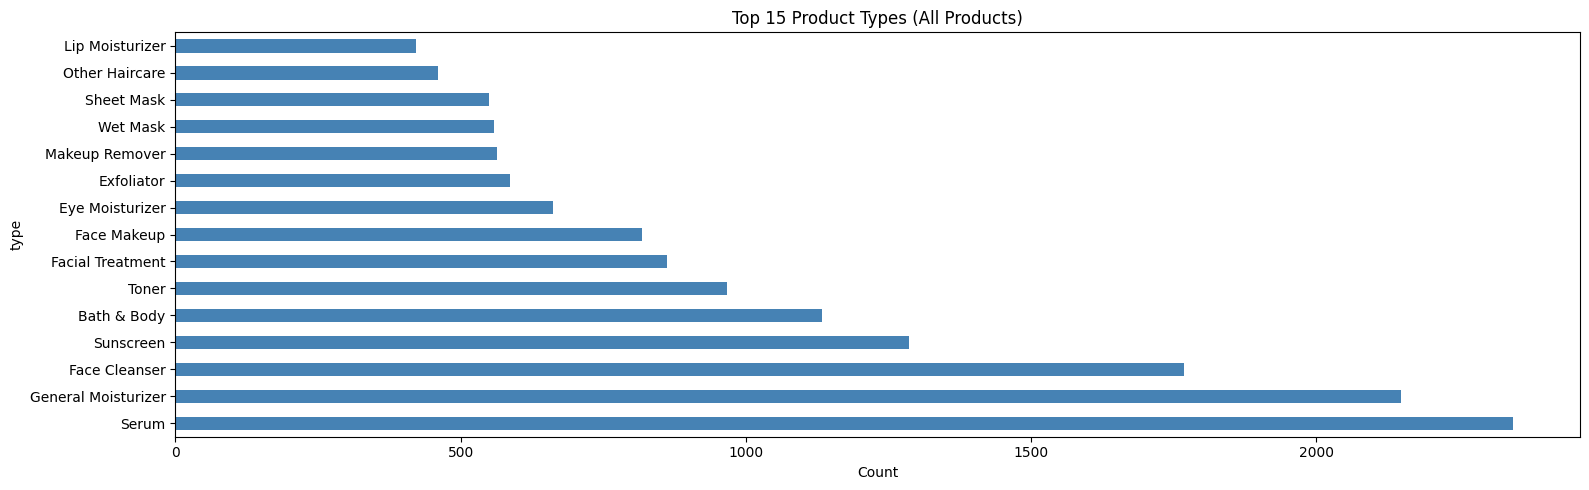

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Product type distribution
fig, axes = plt.subplots(1, 1, figsize=(16, 5))

# Top 15 product types
df_raw['type'].value_counts().head(15).plot(
    kind='barh', ax=axes, color='steelblue'
)
axes.set_title('Top 15 Product Types (All Products)')
axes.set_xlabel('Count')


plt.tight_layout()
plt.show()

**Product types:**
From this chart we can see the most common skin type products is serum(this is applied to the full data hence in our project we're working only on face skin products),the use of this column depend on the correlation with the target

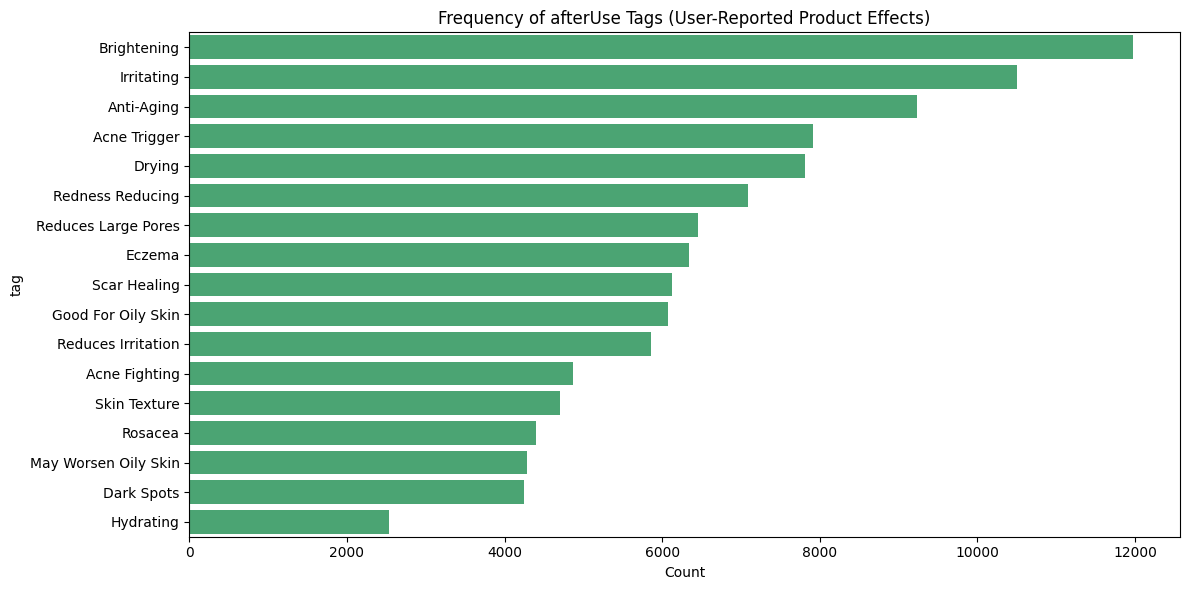


All unique afterUse tags and their frequencies:
                 tag  count
         Brightening  11972
          Irritating  10501
          Anti-Aging   9230
        Acne Trigger   7909
              Drying   7810
    Redness Reducing   7083
 Reduces Large Pores   6452
              Eczema   6337
        Scar Healing   6122
  Good For Oily Skin   6078
  Reduces Irritation   5862
       Acne Fighting   4872
        Skin Texture   4704
             Rosacea   4397
May Worsen Oily Skin   4285
          Dark Spots   4248
           Hydrating   2532


In [9]:
# All unique afterUse tags
#collect all tags from after use
all_tags = []
for row in df_raw['afterUse'].dropna():
    all_tags.extend([t.strip() for t in str(row).split(',')])

tag_counts = Counter(all_tags)

tags_df = pd.DataFrame(tag_counts.most_common(), columns=['tag', 'count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=tags_df, y='tag', x='count', color='mediumseagreen')
plt.title('Frequency of afterUse Tags (User-Reported Product Effects)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

print('\nAll unique afterUse tags and their frequencies:')
print(tags_df.to_string(index=False))

**AfterUse column**
In our dataset, the afterUse column contains the effects of the product after use. From this, we can extract the skin types and concerns associated with each product.

**filter only to face skin products & removing rows that are missing ingredients or afteruse**

In [10]:
SKINCARE_TYPES = [
    'Serum', 'General Moisturizer', 'Face Cleanser', 'Sunscreen',
    'Toner', 'Facial Treatment', 'Exfoliator', 'Wet Mask',
    'Sheet Mask', 'Day Moisturizer', 'Oil', 'Night Moisturizer',
    'Essence', 'Overnight Mask', 'Eye Moisturizer', 'Emulsion'
]
#keep only face products
face_products = df_raw[df_raw['type'].isin(SKINCARE_TYPES)].copy()
print(f'After product type filter: {len(face_products):,} products')

# Drop rows missing ingredients or afterUse
face_products= face_products.dropna(subset=['ingridients', 'afterUse']).reset_index(drop=True)
print(f'After dropping nulls: {len(face_products):,} products')
print(f'Removed: {len(df_raw) - len(face_products):,} rows')

print()
print('Product type breakdown after filtering:')
print(face_products['type'].value_counts())

After product type filter: 13,323 products
After dropping nulls: 12,495 products
Removed: 6,555 rows

Product type breakdown after filtering:
type
Serum                  2199
General Moisturizer    2083
Face Cleanser          1689
Sunscreen              1277
Toner                   865
Facial Treatment        732
Eye Moisturizer         648
Exfoliator              549
Wet Mask                503
Sheet Mask              497
Day Moisturizer         349
Night Moisturizer       317
Oil                     275
Essence                 259
Overnight Mask          191
Emulsion                 62
Name: count, dtype: int64


In [11]:
num_types = face_products['type'].nunique()
print(f"Number of product types: {num_types}")

Number of product types: 16


**distibution of skincare face products**

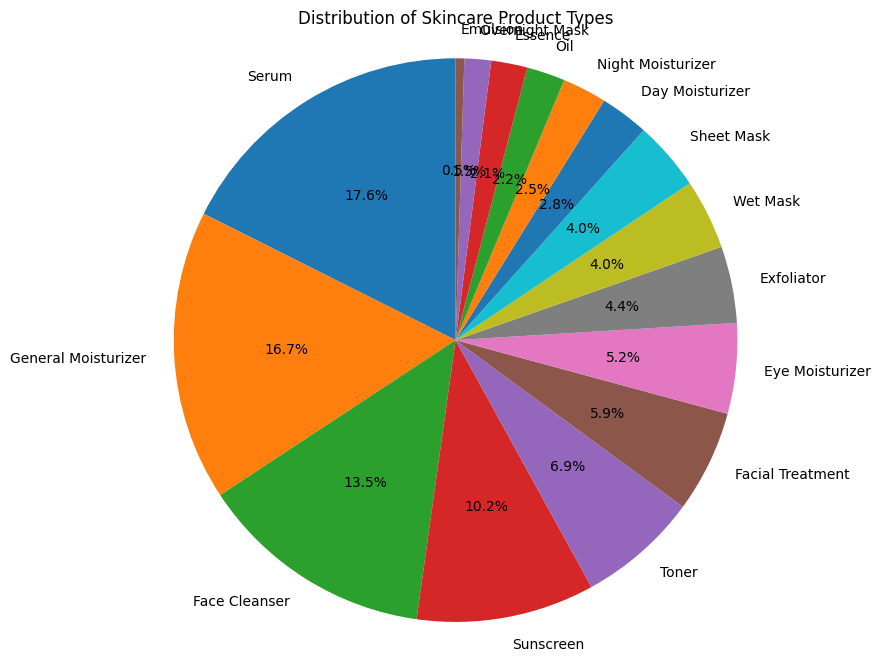

In [12]:
import matplotlib.pyplot as plt

# Count products per type
type_counts = face_products['type'].value_counts()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Skincare Product Types')
plt.axis('equal')  # Makes it a circle
plt.show()

Even after cleaning and filtering, we still retain a significant amount of data.
Note:Class imbalance across product types is less important since it is used as a feature rather than the target variable

<Axes: xlabel='count', ylabel='type'>

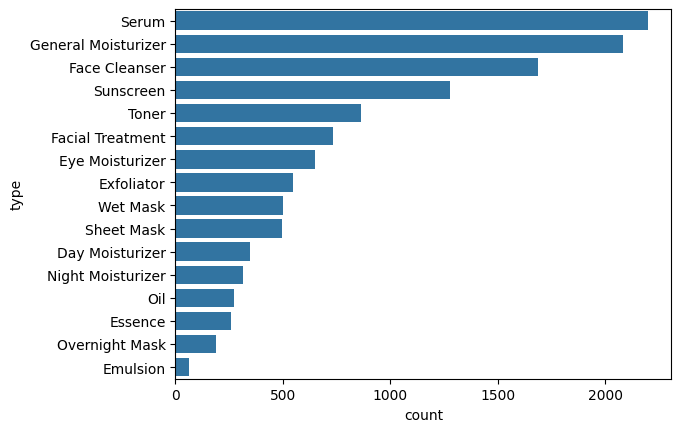

In [13]:
sns.countplot(data=face_products, y='type', order=face_products['type'].value_counts().index)

Product types is imbalanced,the imbalance reflects real-world product availability as serums and mosturizers are most likely to exist and be used for skincare

**Turning text tags into skin-type labels**

In this step, we use the afterUse column to create new skin-type columns.This is done by mapping tags to skin types based on general skincare knowledge and explicit tag meanings. For example, “Good For Oily Skin” indicates that a product is suitable for oily skin, while “Drying” means the product is not suitable for dry skin, so it is assigned a value of 0.

In [14]:
def get_tags(afteruse_str):
    return set(t.strip() for t in str(afteruse_str).split(','))

def derive_skin_labels(afteruse_str):
    tags = get_tags(afteruse_str)

    # Dry skin
    dry = 1 if any(t in tags for t in [
        'Hydrating', 'Anti-Aging', 'Scar Healing'
    ]) else 0

    # Oily skin

    oily_signals = sum([
        'Good For Oily Skin' in tags,
        'Acne Fighting'       in tags,
        'Reduces Large Pores' in tags
    ])
    oily = 1 if oily_signals >= 2 else 0

    # Normal skin
    normal = 1 if any(t in tags for t in [
        'Skin Texture', 'Dark Spots'
    ]) else 0

    # Combination = oily + normal signals together
    combination = 1 if (oily == 1 and normal == 1) else 0

    # Sensitive skin
    has_ri  = 'Reduces Irritation' in tags
    has_rr  = 'Redness Reducing'   in tags
    has_irr = 'Irritating'         in tags
    sensitive = 1 if (has_ri and not has_irr) or (has_ri and has_rr) else 0

    # Negative overrides
    if 'Drying' in tags and 'Hydrating' not in tags:
        dry = 0
    if 'May Worsen Oily Skin' in tags and 'Good For Oily Skin' not in tags:
        oily = 0

    return pd.Series({
        'Dry': dry, 'Oily': oily, 'Normal': normal,
        'Combination': combination, 'Sensitive': sensitive
    })

# Apply labeling
skin_labels = face_products['afterUse'].apply(derive_skin_labels).reset_index(drop=True)
face_products = face_products.reset_index(drop=True)
face_products = pd.concat([face_products, skin_labels], axis=1)

skin_cols = ['Dry', 'Oily', 'Normal', 'Combination', 'Sensitive']

# Save count before dropping
before_drop = len(face_products)

# Drop products with 0 labels
face_products = face_products[
    face_products[skin_cols].sum(axis=1) > 0
].reset_index(drop=True)

**Note:** For oily skin, we require at least two signals because some individual signals appear in many products, which can bias the model to classify products as suitable for oily skin regardless of their specific ingredients.

**Exploring skin types distribution**

In [15]:
print('SKIN TYPE LABEL RATES')
print(face_products[skin_cols].mean().round(3))
print()
print('Labels per product:')
print(face_products[skin_cols].sum(axis=1).value_counts().sort_index())
print()
print(f'Products with at least 1 label: {len(face_products):,}')
print(f'Products dropped (0 labels):    {before_drop - len(face_products):,}')
print()
print('Balance check:')
for col in skin_cols:
    rate = face_products[col].mean()
    bal  = 'balanced' if 0.35 < rate < 0.65 else 'IMBALANCED'
    print(f'  {col:15} {rate:.2%}  ({bal})')

SKIN TYPE LABEL RATES
Dry            0.530
Oily           0.491
Normal         0.443
Combination    0.260
Sensitive      0.357
dtype: float64

Labels per product:
1    3981
2    2391
3    1893
4     867
5     378
Name: count, dtype: int64

Products with at least 1 label: 9,510
Products dropped (0 labels):    2,985

Balance check:
  Dry             52.99%  (balanced)
  Oily            49.13%  (balanced)
  Normal          44.33%  (balanced)
  Combination     26.05%  (IMBALANCED)
  Sensitive       35.71%  (balanced)


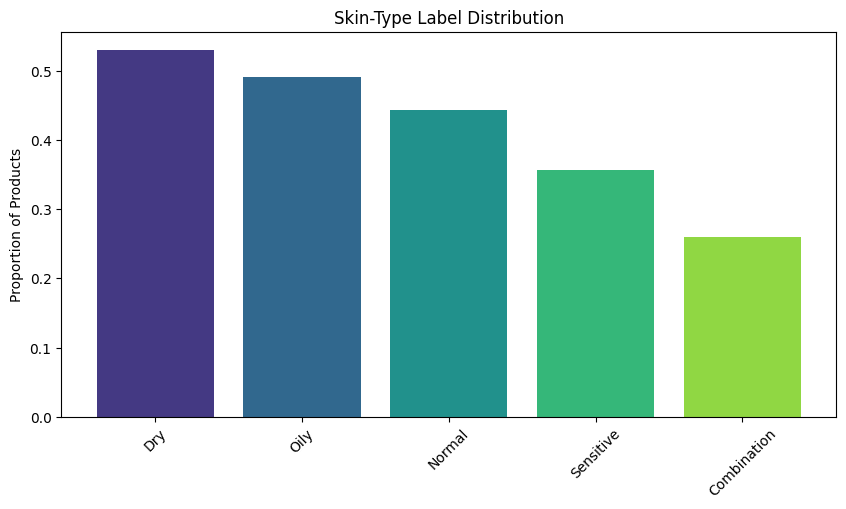

In [16]:
label_rates = face_products[skin_cols].mean().sort_values(ascending=False)

colors = sns.color_palette("viridis", len(label_rates))

plt.figure(figsize=(10, 5))
plt.bar(label_rates.index, label_rates.values, color=colors)

plt.title('Skin-Type Label Distribution')
plt.ylabel('Proportion of Products')
plt.xticks(rotation=45)
plt.show()

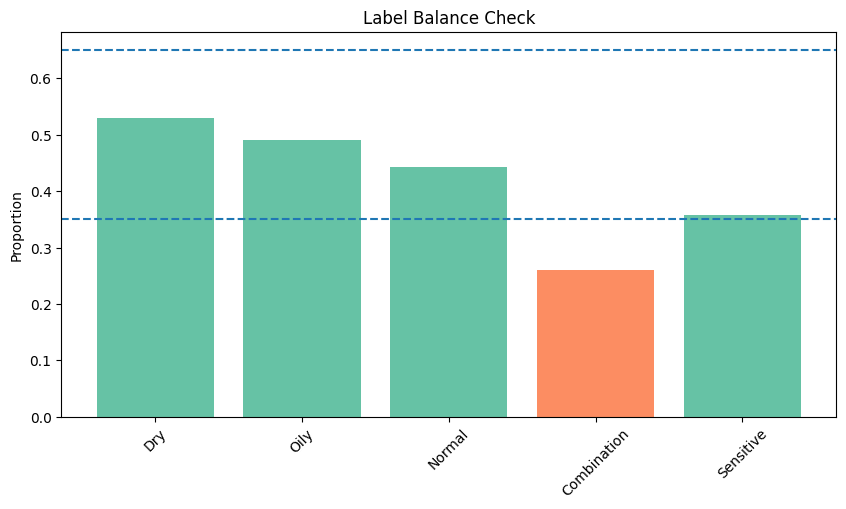

In [17]:
label_rates = face_products[skin_cols].mean()

colors = [
    sns.color_palette("Set2")[0] if 0.35 < r < 0.65
    else sns.color_palette("Set2")[1]
    for r in label_rates
]

plt.figure(figsize=(10, 5))
plt.bar(label_rates.index, label_rates.values, color=colors)

plt.axhline(0.35, linestyle='--')
plt.axhline(0.65, linestyle='--')

plt.title('Label Balance Check')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.show()

The dataset shows a mild class imbalance. Most classes (Dry, Oily, Normal, Sensitive) fall within an acceptable range, however the Combination class is notably underrepresented .

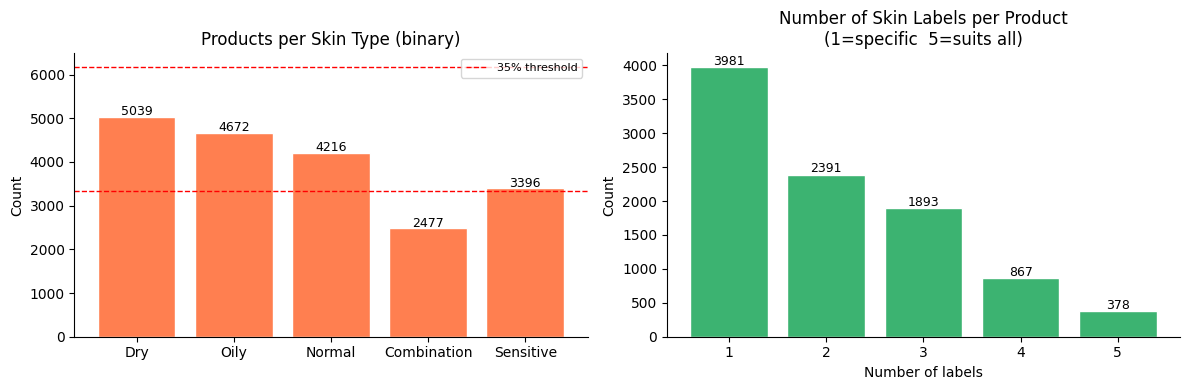

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

skin_cols = ['Dry', 'Oily', 'Normal', 'Combination', 'Sensitive']

# Binary prevalence
binary_sums = face_products[skin_cols].sum()
bars = axes[0].bar(binary_sums.index, binary_sums.values, color='coral', edgecolor='white')
axes[0].set_title('Products per Skin Type (binary)')
axes[0].set_ylabel('Count')
axes[0].axhline(y=len(face_products)*0.35, color='red', linestyle='--', linewidth=1, label='35% threshold')
axes[0].axhline(y=len(face_products)*0.65, color='red', linestyle='--', linewidth=1)
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, binary_sums.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 30, str(v), ha='center', fontsize=9)

# Labels per product
label_counts = face_products[skin_cols].sum(axis=1).value_counts().sort_index()
bars2 = axes[1].bar(label_counts.index.astype(str), label_counts.values, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Number of Skin Labels per Product\n(1=specific  5=suits all)')
axes[1].set_xlabel('Number of labels')
axes[1].set_ylabel('Count')
axes[1].spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars2, label_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 30, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

 After making the Oily condition to require 2+ signals, all five skin types fall within an acceptable range, with Combination being lower Most products carry 1 to 2 labels, meaning the model will have specific, meaningful targets to learn from rather than noisy overlapping signals.

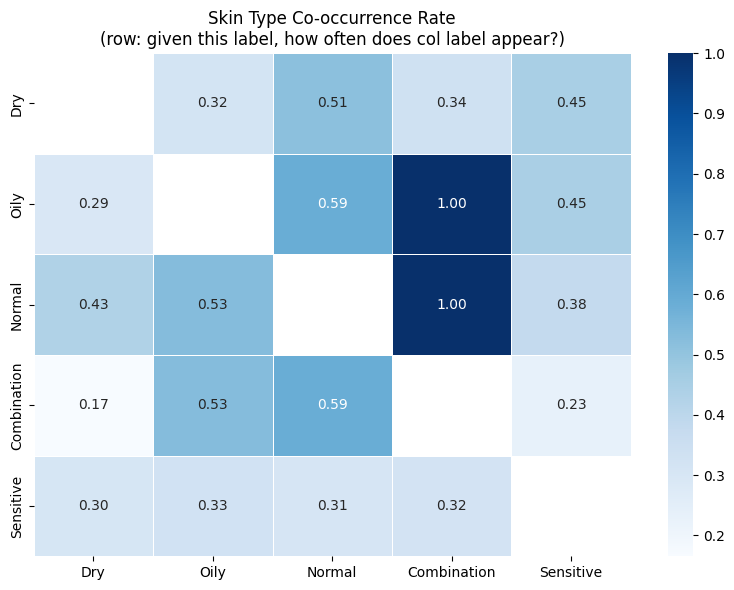

In [19]:
cooccurrence = face_products[skin_cols].T.dot(face_products[skin_cols])
diag = np.diag(cooccurrence.values)
cooccurrence_rate = cooccurrence / diag

plt.figure(figsize=(8, 6))
sns.heatmap(
    cooccurrence_rate,
    annot=True, fmt='.2f',
    cmap='Blues', linewidths=0.5,
    mask=np.eye(len(skin_cols), dtype=bool)
)
plt.title('Skin Type Co-occurrence Rate\n(row: given this label, how often does col label appear?)')
plt.tight_layout()
plt.show()

Skin type labels follow biologically logical patterns:
Combination skin always co-occurs with Oily and Normal
The 0.29 relation that exists for dry and oily is explained by Combination skin

## **Turning tags into concerns**

In [20]:
# Use the first mapping (Anti-aging last — better overall distribution)
def derive_concern(afteruse_str):
    tags = get_tags(afteruse_str)
    if 'Acne Fighting'       in tags: return 'Acne'
    if 'Eczema'              in tags: return 'Eczema'
    if 'Rosacea'             in tags: return 'Redness'
    if 'Dark Spots'          in tags: return 'Hyperpigmentation'
    if 'Scar Healing'        in tags: return 'Hyperpigmentation'
    if 'Hydrating'           in tags: return 'Dryness'
    if 'Reduces Irritation'  in tags: return 'Sensitivity'
    if 'Redness Reducing'    in tags: return 'Redness'
    if 'Reduces Large Pores' in tags: return 'Acne'
    if 'Skin Texture'        in tags: return 'Hyperpigmentation'
    if 'Good For Oily Skin'  in tags: return 'Acne'
    if 'Anti-Aging'          in tags: return 'Anti-aging'
    return 'Dryness'

face_products['primary_concern'] = face_products['afterUse'].apply(derive_concern)

# Then merge Anti-aging (55 samples) into Hyperpigmentation
# Both target skin aging signs — dark spots, texture, fine lines overlap
face_products['primary_concern'] = face_products['primary_concern'].replace({
    'Anti-aging': 'Hyperpigmentation'
})

print('FINAL CONCERN DISTRIBUTION')
print(face_products['primary_concern'].value_counts())
print(f'\nTotal classes: {face_products["primary_concern"].nunique()}')

FINAL CONCERN DISTRIBUTION
primary_concern
Acne                 4215
Hyperpigmentation    2046
Eczema               1299
Sensitivity           815
Redness               736
Dryness               399
Name: count, dtype: int64

Total classes: 6


The derive_concern function checks tags in a fixed order and returns the first match, so whichever condition appears earliest in the chain wins This means order directly controls which label gets assigned when a product has multiple tags.

**distribution check for skin concern**

In [21]:
# Counts
counts = face_products['primary_concern'].value_counts()

# Percentages
percentages = face_products['primary_concern'].value_counts(normalize=True) * 100

# Combine into one table
distribution = counts.to_frame(name='count')
distribution['percentage'] = percentages.round(2)

print(distribution)

                   count  percentage
primary_concern                     
Acne                4215       44.32
Hyperpigmentation   2046       21.51
Eczema              1299       13.66
Sensitivity          815        8.57
Redness              736        7.74
Dryness              399        4.20


/tmp/ipykernel_23312/440486492.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


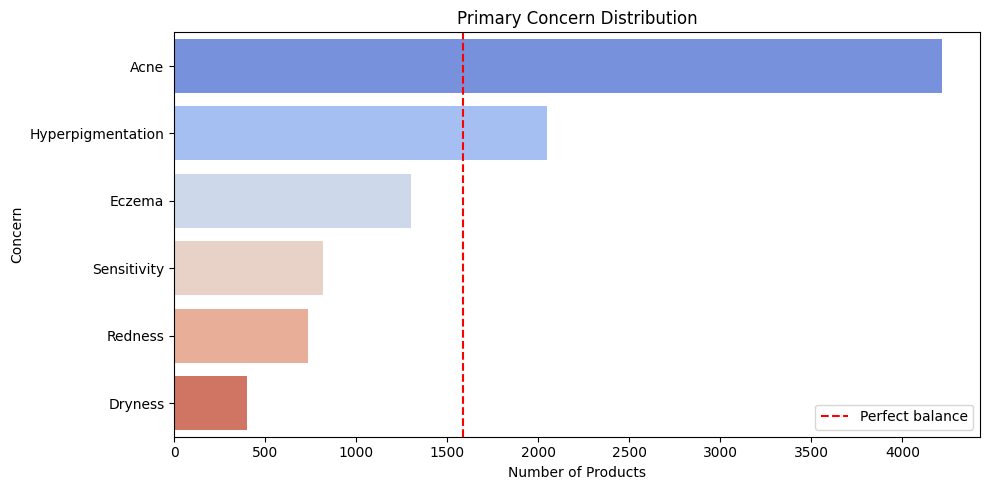

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=face_products['primary_concern'].value_counts().values,
    y=face_products['primary_concern'].value_counts().index,
    palette='coolwarm'
)
plt.axvline(x=len(face_products) / face_products['primary_concern'].nunique(),
            color='red', linestyle='--', label='Perfect balance')
plt.title('Primary Concern Distribution')
plt.xlabel('Number of Products')
plt.ylabel('Concern')
plt.legend()
plt.tight_layout()
plt.show()

The primary concern distribution is significantly imbalanced. Acne dominates by a large margin,while Hyperpigmentation is the only other class that crosses it. The remaining classes Eczema, Sensitivity, and Redness fall notably short, and Dryness is the most underrepresented of all. This imbalance shows that we will need class weighting .

**Skin Type vs product type **

In [23]:
pd.crosstab(face_products['type'], face_products[skin_cols].idxmax(axis=1), normalize='index')

col_0,Dry,Normal,Oily,Sensitive
type,,,,
Day Moisturizer,0.581967,0.045082,0.311475,0.061475
Emulsion,0.600000,0.022222,0.133333,0.244444
Essence,0.650224,0.035874,0.255605,0.058296
Exfoliator,0.311594,0.026570,0.603865,0.057971
Eye Moisturizer,0.633752,0.052065,0.253142,0.061041
Face Cleanser,0.390093,0.068111,0.404541,0.137255
Facial Treatment,0.386023,0.033278,0.515807,0.064892
General Moisturizer,0.619650,0.037975,0.245931,0.096444
Night Moisturizer,0.447368,0.030075,0.451128,0.071429


The strong association between product type and skin type shows overlap rather than a genuinely learned signal. Since both variables describe product characteristics, using product type as a feature for skin type prediction risks introducing indirect leakage

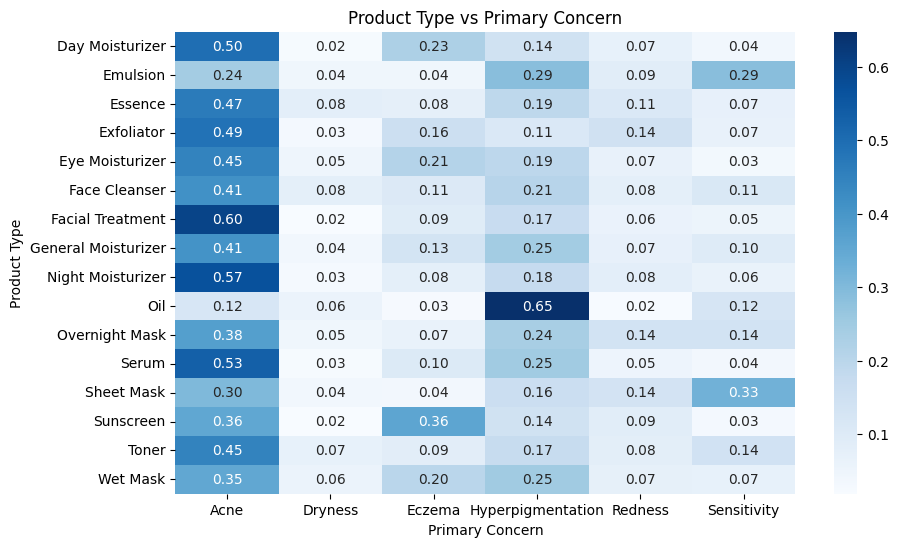

In [24]:
ct = pd.crosstab(
    face_products['type'],
    face_products['primary_concern'],
    normalize='index'
)

plt.figure(figsize=(10,6))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")

plt.title("Product Type vs Primary Concern")
plt.xlabel("Primary Concern")
plt.ylabel("Product Type")

plt.show()

 product type have a real relationship with concern but it's moderate it might add context
 -->use product type for skin concern prediction model

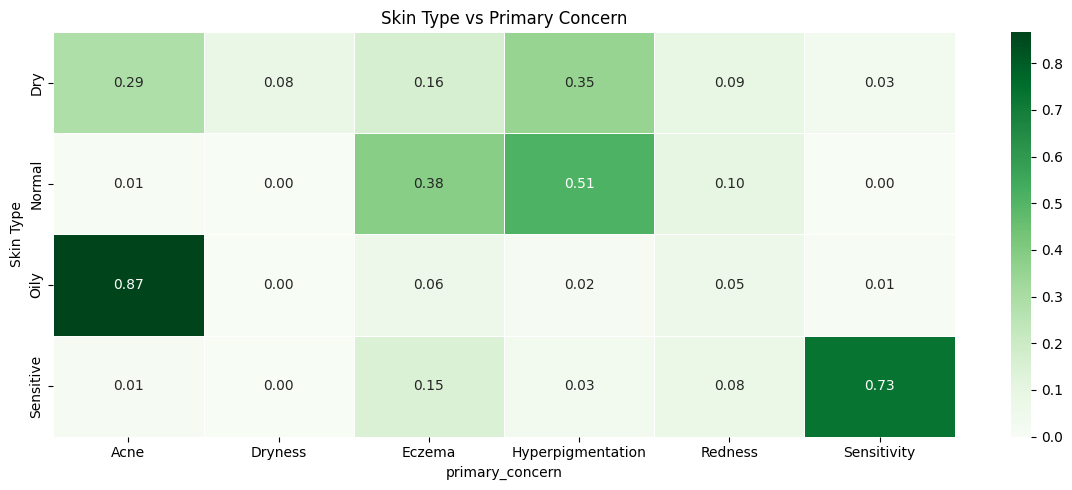

In [25]:
#Skin Type vs Primary Concern
fig, ax = plt.subplots(figsize=(12, 5))
skin_concern = pd.crosstab(face_products[skin_cols].idxmax(axis=1), face_products['primary_concern'], normalize='index')
sns.heatmap(skin_concern, annot=True, fmt='.2f', cmap='Greens', linewidths=0.5, ax=ax)
ax.set_title('Skin Type vs Primary Concern')
ax.set_ylabel('Skin Type')
plt.tight_layout()
plt.show()

Skin type and primary concern both were derived from the same column making their relationship strong rather than genuinely learned. Using one to predict the other would is considered data leakage-->both won't be used for each other prediction

**Ages mapping based on skin concern**

we chose to map age based on skin concern cause it's the most bilogically explainable as Certain concerns are more prevalent at certain ages,it was engineered using clinically informed probability distributions example acne-concerned products are more likely purchased by younger users, while anti-aging products is mostly used by older the probabilities are generated with some randomness so the results don’t always come out exactly the same.

In [26]:
np.random.seed(42)

AGE_CONCERN_PROBS = {
    'Acne':              {'18-25': 0.50, '26-35': 0.35, '36-45': 0.10, '46-55': 0.04, '56+': 0.01},
    'Hyperpigmentation': {'18-25': 0.10, '26-35': 0.25, '36-45': 0.30, '46-55': 0.22, '56+': 0.13},
    'Eczema':            {'18-25': 0.20, '26-35': 0.28, '36-45': 0.25, '46-55': 0.18, '56+': 0.09},
    'Sensitivity':       {'18-25': 0.18, '26-35': 0.28, '36-45': 0.26, '46-55': 0.18, '56+': 0.10},
    'Redness':           {'18-25': 0.15, '26-35': 0.25, '36-45': 0.28, '46-55': 0.20, '56+': 0.12},
    'Dryness':           {'18-25': 0.12, '26-35': 0.25, '36-45': 0.28, '46-55': 0.22, '56+': 0.13},
}

DEFAULT_AGE_PROBS = {'18-25': 0.18, '26-35': 0.26, '36-45': 0.24, '46-55': 0.18, '56+': 0.14}

def derive_age(concern):
    probs = AGE_CONCERN_PROBS.get(concern, DEFAULT_AGE_PROBS)
    ages  = list(probs.keys())
    wts   = np.array(list(probs.values()))
    wts   = wts / wts.sum()
    return np.random.choice(ages, p=wts)

face_products['age_group'] = face_products['primary_concern'].apply(derive_age)

print('AGE GROUP DISTRIBUTION')
print(face_products['age_group'].value_counts().sort_index())
print()
print('Sanity check — teens more Acne, older more Hyperpigmentation/Dryness:')
ct = pd.crosstab(
    face_products['age_group'],
    face_products['primary_concern'],
    normalize='index'
).round(2)
print(ct[['Acne', 'Hyperpigmentation', 'Dryness', 'Sensitivity']].to_string())

AGE GROUP DISTRIBUTION
age_group
18-25    2969
26-35    2838
36-45    1883
46-55    1188
56+       632
Name: count, dtype: int64

Sanity check — teens more Acne, older more Hyperpigmentation/Dryness:
primary_concern  Acne  Hyperpigmentation  Dryness  Sensitivity
age_group                                                     
18-25            0.73               0.07     0.02         0.06
26-35            0.52               0.18     0.04         0.08
36-45            0.20               0.34     0.06         0.11
46-55            0.14               0.35     0.08         0.12
56+              0.05               0.43     0.06         0.12


**Age distribution**

In [27]:
# Counts
age_counts = face_products['age_group'].value_counts().sort_index()

# Percentages
age_percentages = face_products['age_group'].value_counts(normalize=True).sort_index() * 100

# Combine
age_distribution = age_counts.to_frame(name='count')
age_distribution['percentage'] = age_percentages.round(2)

print('AGE GROUP DISTRIBUTION (COUNT + %)')
print(age_distribution)

AGE GROUP DISTRIBUTION (COUNT + %)
           count  percentage
age_group                   
18-25       2969       31.22
26-35       2838       29.84
36-45       1883       19.80
46-55       1188       12.49
56+          632        6.65


Age group distribution follows a natural declining pattern from younger to older groups with mild imbalance acceptable for modeling. However since age was derived from concern probability distributions rather than independent real-world data, the distribution reflects concern patterns more than real age-based behavior, making it a weak prediction target.

**Primary concern vs age group**

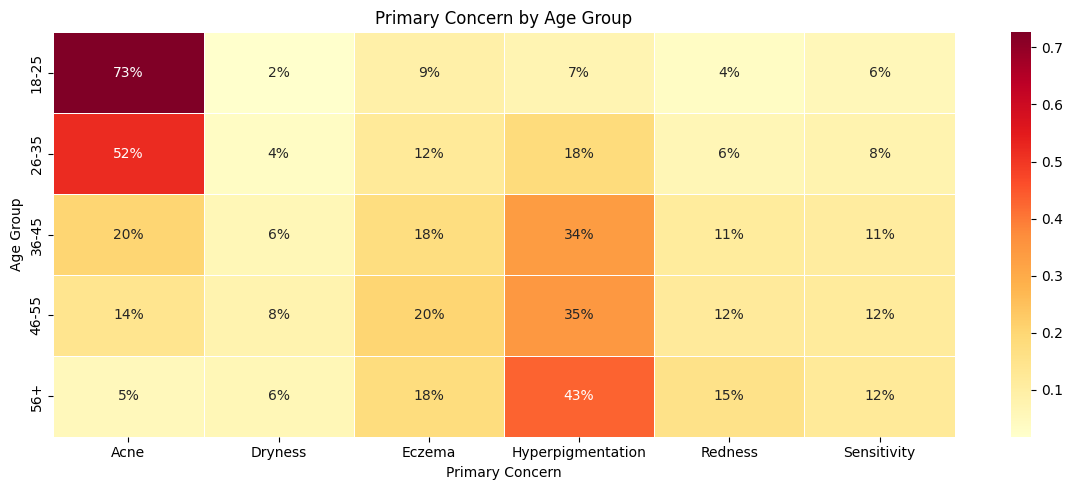

In [28]:
ct = pd.crosstab(face_products['age_group'], face_products['primary_concern'], normalize='index')

plt.figure(figsize=(12, 5))
sns.heatmap(ct, annot=True, fmt='.0%', cmap='YlOrRd', linewidths=0.5)
plt.title('Primary Concern by Age Group')
plt.xlabel('Primary Concern')
plt.ylabel('Age Group')
plt.tight_layout()
plt.show()

Darker cells = that concern dominates that age
the plot shows that acne  shows domination for specific age categories  ,Dryness, eczema, Sensitivity, Redness stays flat across ages this might suggest that age is a strong predictor for Acne, but weak for the rest. So age is a useful feature but not sufficient on its own(however age was dervied from skin concern which lead us to not use it for prediction because it shows data leakge)


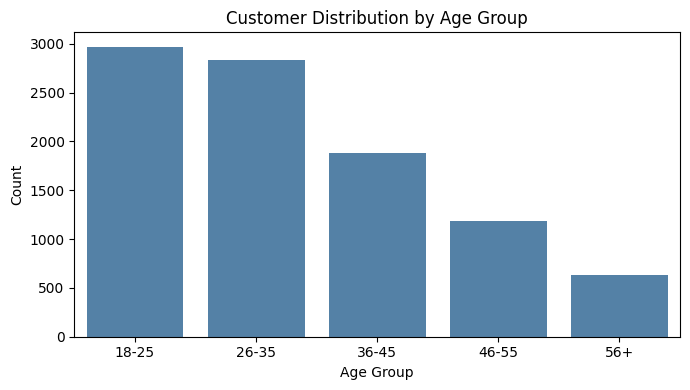

In [29]:
plt.figure(figsize=(7, 4))
sns.countplot(data=face_products, x='age_group',
              order=['18-25','26-35','36-45','46-55','56+'],
              color='steelblue')
plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

realtively balanced nearly identical at first that declines,It's not perfectly uniform but there's no extreme outlier

**Age Group vs skin type**

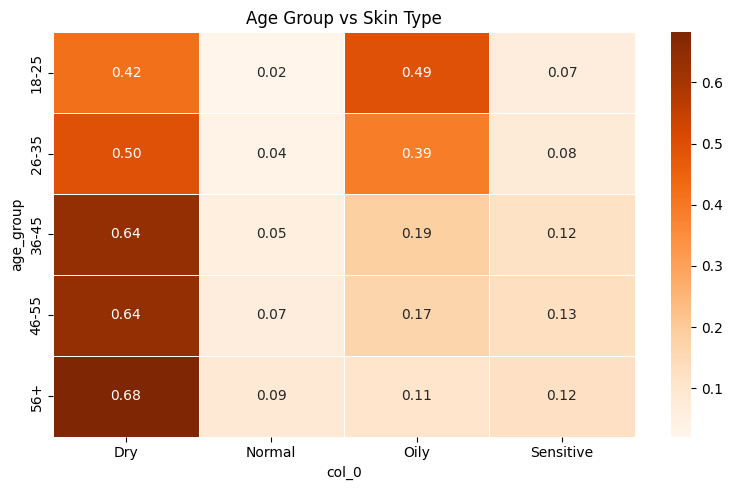

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
age_skin = pd.crosstab(face_products['age_group'], face_products[skin_cols].idxmax(axis=1), normalize='index')
sns.heatmap(age_skin, annot=True, fmt='.2f', cmap='Oranges', linewidths=0.5, ax=ax)
ax.set_title('Age Group vs Skin Type')
plt.tight_layout()
plt.show()

Age group shows a meaningful relationship with skin type, making it a valuable feature for predicting skin typeH ,However, the reverse is weaker: using skin type to predict age group is less reliable since skin types like Dry appear across all age groups without a specific age signal.(same as skin concern)

**Age group vs product type**

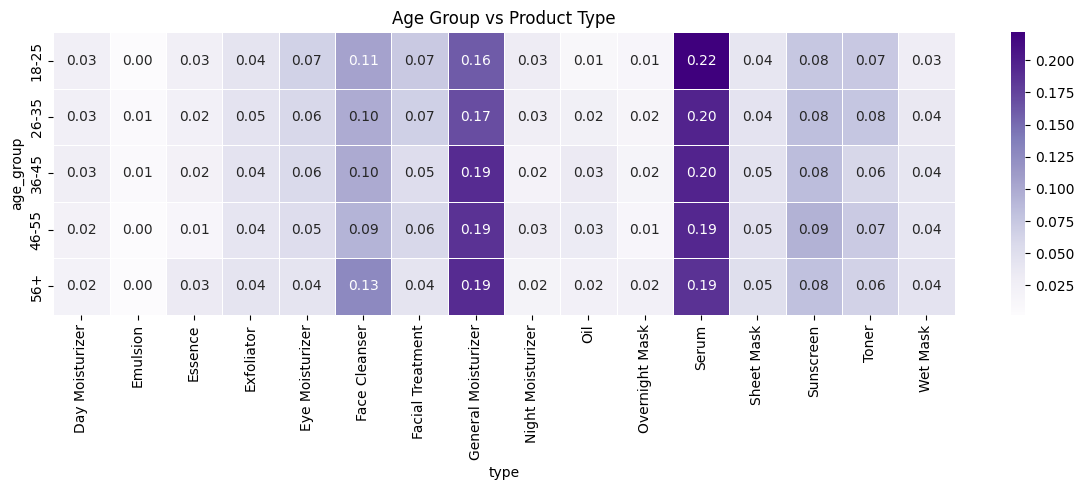

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
age_product = pd.crosstab(face_products['age_group'], face_products['type'], normalize='index')
sns.heatmap(age_product, annot=True, fmt='.2f', cmap='Purples', linewidths=0.5, ax=ax)
ax.set_title('Age Group vs Product Type')
plt.tight_layout()
plt.show()

Product type distribution is nearly identical across all age groups This means product type carries almost no signal for predicting age group
-->product type won't be used to detect age

In [32]:
print(face_products.shape)

(9510, 13)


In [33]:
print(face_products.isna().sum())

brand                0
name                 0
type                 0
country            819
ingridients          0
afterUse             0
Dry                  0
Oily                 0
Normal               0
Combination          0
Sensitive            0
primary_concern      0
age_group            0
dtype: int64


**Removing irrelvant columns**

In [34]:
#removing column that are not signficant for my models
cols_to_keep = [
    'ingridients',
    'Dry', 'Oily', 'Normal', 'Combination', 'Sensitive',
    'primary_concern',
    'age_group',
    'type'
]

skinCare_df= face_products[cols_to_keep].copy()
print(skinCare_df.shape)
skinCare_df

(9510, 9)


,ingridients,Dry,Oily,Normal,Combination,Sensitive,primary_concern,age_group,type
0,"Water,Glycolic Acid,Rosa Damascena Flower Wate...",0,1,1,1,0,Redness,26-35,Toner
1,"Water,Glycerin,Pentaerythrityl Tetraethylhexan...",0,1,0,0,1,Acne,46-55,Face Cleanser
2,"Water,Niacinamide,Pentylene Glycol,Zinc PCA,Di...",0,1,0,0,0,Acne,26-35,Facial Treatment
3,"Water,Cocamidopropyl Hydroxysultaine,Sodium Co...",0,0,1,0,1,Hyperpigmentation,36-45,Face Cleanser
4,"Water,Cocamidopropyl Betaine,Sodium Lauroyl Me...",0,1,0,0,0,Sensitivity,18-25,Face Cleanser
...,...,...,...,...,...,...,...,...,...
9505,"Water,Caffeine,Maltodextrin,Glycerin,Propanedi...",0,1,1,1,0,Eczema,26-35,Serum
9506,"Water,Glycerin,Cetearyl Alcohol,Peg-40 Stearat...",1,0,0,0,0,Hyperpigmentation,18-25,Face Cleanser
9507,"Panax Ginseng Root Water,Butylene Glycol,Glyce...",0,1,0,0,1,Acne,26-35,Essence
9508,"Water,Glycerin,Caprylic/Capric Triglyceride,Ni...",1,1,0,0,0,Acne,18-25,Night Moisturizer


In [35]:
#renaming type to product type for clarity
skinCare_df = skinCare_df.rename(columns={'type': 'product_type'})

## **Encoding**
Ingredient

In [36]:
skincare= skinCare_df.copy()

#### TF-IDF for ingredient

* splitting the text by commas so that each ingredient becomes token
converting all text to lowercase for consistency
* merging multi-word ingredients into a single token (e.g., salicylic acid → salicylic_acid).
* TF-IDF was used to convert the text into a numerical matrix.
HyperParameters used :




In [37]:
import re

def clean_ingredients(text):

    text = str(text).lower().strip()
    text = text.replace('.', '').replace('(', '').replace(')', '')
    ingredients = [ing.strip() for ing in text.split(',')]
    ingredients = [re.sub(r'^\d+$', '', ing).strip() for ing in ingredients]
    ingredients = [ing.replace(' ', '_') for ing in ingredients if ing]
    return ' '.join(ingredients)

skincare['ingredients_clean'] = skincare['ingridients'].apply(clean_ingredients)

# Sample check
print('Sample cleaned ingredients:')
for i in range(3):
    print(f'{skincare["ingredients_clean"].iloc[i][:120]}')
print()

# Vocabulary check
all_tokens = []
for row in skincare['ingredients_clean']:
    all_tokens.extend(str(row).split())

from collections import Counter
token_counts = Counter(all_tokens)

print(f'Total unique ingredient tokens: {len(token_counts):,}')
print()
print('Top 15 most common tokens:')
for ing, cnt in token_counts.most_common(15):
    print(f'  {ing:45} {cnt:,}')

Sample cleaned ingredients:
water glycolic_acid rosa_damascena_flower_water centaurea_cyanus_flower_water aloe_barbadensis_leaf_water propanediol gl
water glycerin pentaerythrityl_tetraethylhexanoate propylene_glycol ammonium_polyacryloyldimethyl_taurate polysorbate_60
water niacinamide pentylene_glycol zinc_pca dimethyl_isosorbide tamarindus_indica_seed_gum xanthan_gum isoceteth-20 etho

Total unique ingredient tokens: 7,527

Top 15 most common tokens:
  water                                         8,172
  glycerin                                      7,500
  butylene_glycol                               4,409
  phenoxyethanol                                4,127
  ethylhexylglycerin                            4,111
  sodium_hyaluronate                            3,662
  xanthan_gum                                   3,541
  disodium_edta                                 3,408
  tocopherol                                    3,375
  2-hexanediol                                  3,011
  

* The vocabulary contains 7,527 unique
ingredients across all products.
Of these

* 3,000+ appear in at least 5 products and are considered
reliable for modeling.

* water and glycerin appear in almost every product

**Exploration & Analysis**

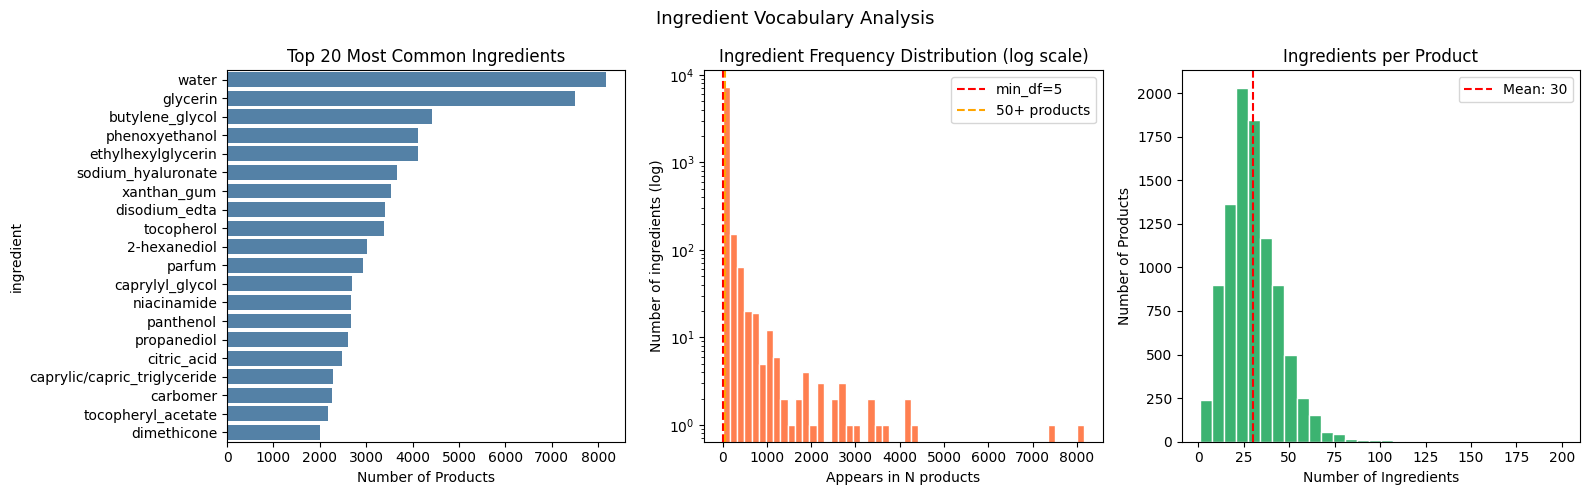

Average ingredients per product: 30.3
Min: 1  Max: 200


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Top 20 most common ingredients
top20 = pd.DataFrame(token_counts.most_common(20), columns=['ingredient', 'count'])
sns.barplot(data=top20, y='ingredient', x='count', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Most Common Ingredients')
axes[0].set_xlabel('Number of Products')

# Plot 2: Frequency distribution how many ingredients appear in N products
freq_dist = pd.Series(list(token_counts.values()))
axes[1].hist(freq_dist, bins=50, color='coral', edgecolor='white', log=True)
axes[1].set_title('Ingredient Frequency Distribution (log scale)')
axes[1].set_xlabel('Appears in N products')
axes[1].set_ylabel('Number of ingredients (log)')
axes[1].axvline(x=5,  color='red',    linestyle='--', label='min_df=5')
axes[1].axvline(x=50, color='orange', linestyle='--', label='50+ products')
axes[1].legend()

# Plot 3: Ingredient count per product
skincare['ing_count'] = skincare['ingredients_clean'].apply(
    lambda x: len(str(x).split())
)
axes[2].hist(skincare['ing_count'], bins=30, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Ingredients per Product')
axes[2].set_xlabel('Number of Ingredients')
axes[2].set_ylabel('Number of Products')
axes[2].axvline(x=skincare['ing_count'].mean(),
                color='red', linestyle='--',
                label=f'Mean: {skincare["ing_count"].mean():.0f}')
axes[2].legend()

plt.suptitle('Ingredient Vocabulary Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Average ingredients per product: {skincare["ing_count"].mean():.1f}')
print(f'Min: {skincare["ing_count"].min()}  Max: {skincare["ing_count"].max()}')

Most ingredients are rare appearing in only a handful of products.
A small core vocabulary of ingredients appears in 50+ products
and carries the most reliable signal for modeling.

**applying tf-idf**

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=500,  # top 500 from your 3,338 meaningful tokens
    min_df=5,          # must appear in 5+ products
    ngram_range=(1,1), # full ingredient name
    strip_accents='unicode',
    sublinear_tf=True  # log normalization —-> prevents water/glycerin dominating
)

X_tfidf = vectorizer.fit_transform(skincare['ingredients_clean'])
print(f'TF-IDF shape: {X_tfidf.shape}')


TF-IDF shape: (9510, 500)


The ingredient text is converted into a (9510 × 500) sparse matrix.
Each row represents one product, each column represents one ingredient.The value in each cell is the TF-IDF score of that ingredient for that product

In [40]:
skincare1= skincare.copy()

### **Encoding concen & age & product types**

Label encoding for the concern target, One-Hot Encoding for the product type (16 categories, no natural order).

**age encoding**

In [41]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

#age encoding(natural order)
oe_age = OrdinalEncoder(categories=[['18-25', '26-35', '36-45', '46-55', '56+']])
skincare1['age_encoded'] = oe_age.fit_transform(skincare1[['age_group']]).astype(int)

**concern encoding**

In [42]:
#concern encoding(multiclass target)
le_concern = LabelEncoder()
skincare1['concern_encoded'] = le_concern.fit_transform(skincare1['primary_concern'])

In [59]:
le_concern.classes_

array(['Acne', 'Dryness', 'Eczema', 'Hyperpigmentation', 'Redness',
       'Sensitivity'], dtype=object)

**product type encoding**

In [43]:
#Product type: OHE
ohe_product = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
product_feats = ohe_product.fit_transform(skincare1[['product_type']])

In [44]:
ohe_product.categories_

[array(['Day Moisturizer', 'Emulsion', 'Essence', 'Exfoliator',
        'Eye Moisturizer', 'Face Cleanser', 'Facial Treatment',
        'General Moisturizer', 'Night Moisturizer', 'Oil',
        'Overnight Mask', 'Serum', 'Sheet Mask', 'Sunscreen', 'Toner',
        'Wet Mask'], dtype=object)]

**Exploration**

In [45]:
print('Encodings done')
print(f'TF-IDF shape:       {X_tfidf.shape}')
print(f'Product OHE shape:  {product_feats.shape}')
print(f'Concern classes:    {dict(enumerate(le_concern.classes_))}')
print(f'Age mapping:        {skincare1[["age_group","age_encoded"]].drop_duplicates().sort_values("age_encoded").to_string(index=False)}')

Encodings done
TF-IDF shape:       (9510, 500)
Product OHE shape:  (9510, 16)
Concern classes:    {0: 'Acne', 1: 'Dryness', 2: 'Eczema', 3: 'Hyperpigmentation', 4: 'Redness', 5: 'Sensitivity'}
Age mapping:        age_group  age_encoded
    18-25            0
    26-35            1
    36-45            2
    46-55            3
      56+            4


In [46]:
feature_names = vectorizer.get_feature_names_out()
X_dense = X_tfidf.toarray()

**modle 1A skin type**


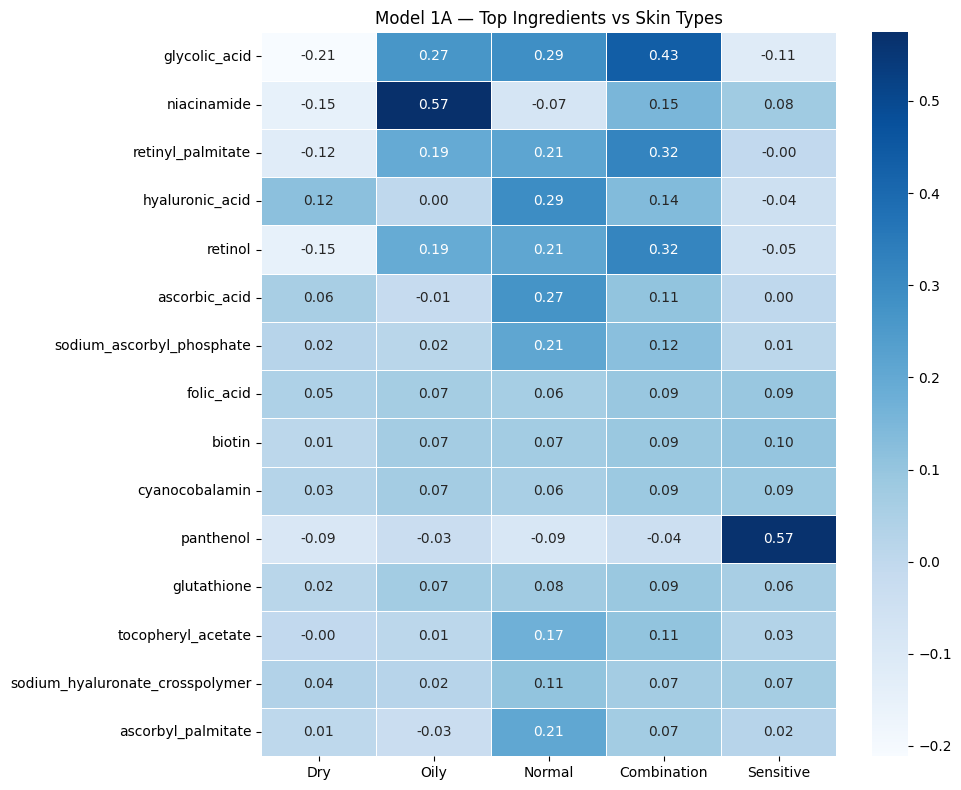

In [47]:
#Ingredients vs Skin Types
feature_names = vectorizer.get_feature_names_out()
X_dense = X_tfidf.toarray()

tfidf_df = pd.DataFrame(X_dense, columns=feature_names)
for col in skin_cols:
    tfidf_df[col] = skincare1[col].values

top_ing_skin = tfidf_df[feature_names].corrwith(
    tfidf_df[skin_cols].mean(axis=1)
).abs().nlargest(15).index.tolist()

corr_1a = tfidf_df[top_ing_skin + skin_cols].corr().loc[top_ing_skin, skin_cols]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_1a, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Model 1A — Top Ingredients vs Skin Types')
plt.tight_layout()
plt.show()

In [49]:
results = {}

for col in skin_cols:
    F, p = f_classif(X_tfidf, skincare1[col])

    df_tmp = pd.DataFrame({
        'feature': feature_names,
        'F_score': F,
        'p_value': p
    }).sort_values('F_score', ascending=False)

    results[col] = df_tmp.head(10)

print("Results for oily skin type:")
print(results['Oily'])
print("\nResults for dry skin type:")
print(results['Dry'])
print("\nResults for normal skin type:")
print(results['Normal'])
print("\nResults for combination skin type:")
print(results['Combination'])
print("\nResults for sensitive skin type:")
print(results['Sensitive'])

NameError: name 'f_classif' is not defined

While ANOVA results confirm that ingredients significantly influence skin type classification, the moderate correlation values and overlapping ingredient usage indicate non-linear and multi-label relationships. This explains why some skin types, such as oily and sensitive, are easier to predict due to distinct ingredient patterns, whereas others like dry and normal are more challenging.

**model 1B -skin concern**

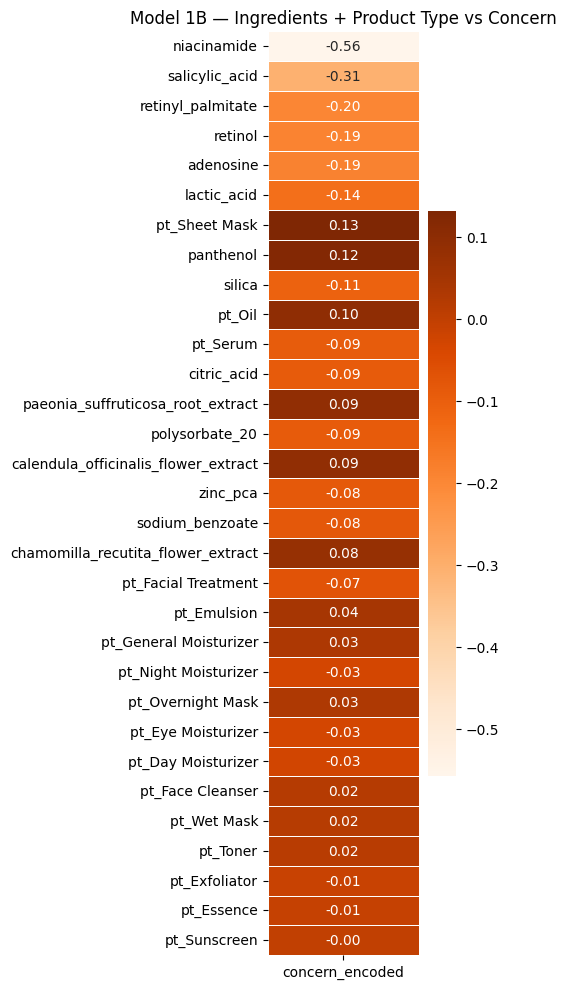

In [50]:
#Correlation Matrix 1B: Ingredients + Product Type vs Concern
top_ing_concern = pd.Series(
    np.corrcoef(X_dense.T, skincare1['concern_encoded'].values)[-1, :-1],
    index=feature_names
).abs().nlargest(15).index.tolist()

concern_corr_df = pd.DataFrame(
    X_dense[:, [list(feature_names).index(i) for i in top_ing_concern]],
    columns=top_ing_concern
)
pt_dummies = pd.get_dummies(skincare1['product_type'], prefix='pt')
concern_corr_df = pd.concat([concern_corr_df, pt_dummies], axis=1)
concern_corr_df['concern_encoded'] = skincare1['concern_encoded'].values

corr_1b = concern_corr_df.corr()[['concern_encoded']].drop('concern_encoded')
corr_1b = corr_1b.reindex(corr_1b['concern_encoded'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(5, 10))
sns.heatmap(corr_1b, annot=True, fmt='.2f', cmap='Oranges', linewidths=0.5, ax=ax)
ax.set_title('Model 1B — Ingredients + Product Type vs Concern')
plt.tight_layout()
plt.show()

In [51]:
#ANOVA F-test for model 1b
from sklearn.feature_selection import f_classif


F, p = f_classif(X_tfidf, skincare1['concern_encoded'])

f_test_df = pd.DataFrame({
    'feature': feature_names,
    'F_score': F,
    'p_value': p
}).sort_values('F_score', ascending=False)

print(f_test_df.head(20))

                      feature      F_score        p_value
315               niacinamide  1314.793264   0.000000e+00
409                    silica   368.786406   0.000000e+00
34                    alcohol   300.112573  3.565810e-299
400            salicylic_acid   267.876945  8.676203e-269
268               lactic_acid   211.908544  5.796961e-215
333                 panthenol   202.620576  6.756809e-206
465                tocopherol   178.924087  1.374021e-182
311                      mica   160.427103  3.236474e-164
228             glycolic_acid   129.916232  1.444004e-133
446                  sorbitol   115.100186  1.577969e-118
343     persea_gratissima_oil   105.895065  3.910684e-109
389         retinyl_palmitate   100.890742  5.194490e-104
32                  adenosine   100.761507  7.046932e-104
388                   retinol    94.128151   4.537872e-97
242           hyaluronic_acid    79.183845   1.169058e-81
72               benzoic_acid    78.161541   1.335331e-80
141  chondrus_

For model 1b prediction of skin concern:
ANOVA F-scores are high while correlations are moderate to weak for skin concerns. This indicates that relationships between ingredients and concerns exist, but they are not purely linear. As a result, linear models may not fully capture these patterns

**Model 1C- Age prediction**

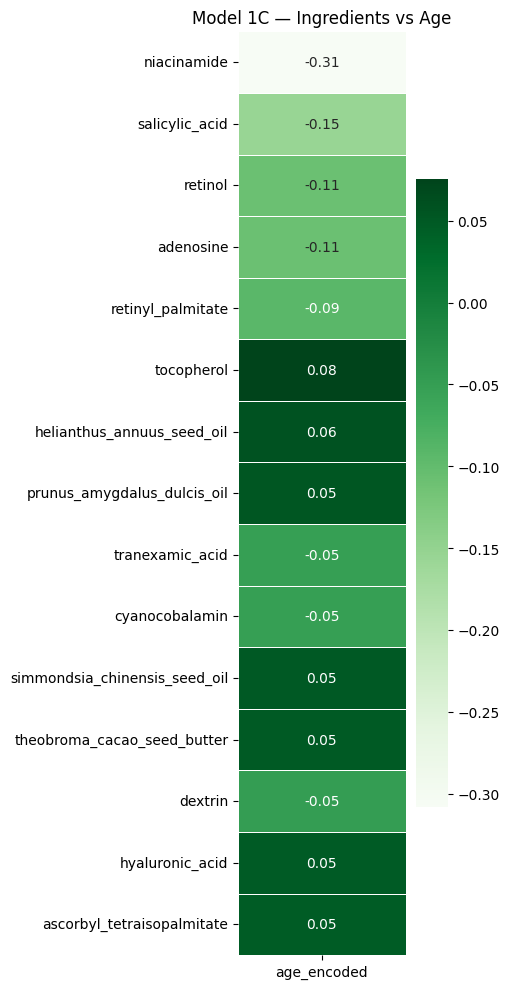

In [52]:
# Correlation Matrix 1C: Ingredients vs Age
top_ing_age = pd.Series(
    np.corrcoef(X_dense.T, skincare1['age_encoded'].values)[-1, :-1],
    index=feature_names
).abs().nlargest(15).index.tolist()

age_corr_df = pd.DataFrame(
    X_dense[:, [list(feature_names).index(i) for i in top_ing_age]],
    columns=top_ing_age
)
age_corr_df['age_encoded'] = skincare1['age_encoded'].values

corr_1c = age_corr_df.corr()[['age_encoded']].drop('age_encoded')
corr_1c = corr_1c.reindex(corr_1c['age_encoded'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(5, 10))
sns.heatmap(corr_1c, annot=True, fmt='.2f', cmap='Greens', linewidths=0.5, ax=ax)
ax.set_title('Model 1C — Ingredients vs Age')
plt.tight_layout()
plt.show()

In [53]:
F_age, p_age = f_classif(X_tfidf, skincare1['age_encoded'])

f_test_age_df = pd.DataFrame({
    'feature': feature_names,
    'F_score': F_age,
    'p_value': p_age
}).sort_values('F_score', ascending=False)

print(f_test_age_df.head(20))

                           feature     F_score        p_value
315                    niacinamide  270.669552  1.095179e-220
400                 salicylic_acid   62.709254   2.129787e-52
32                       adenosine   30.402856   3.511721e-25
388                        retinol   30.025157   7.314650e-25
389              retinyl_palmitate   21.726051   7.223824e-18
465                     tocopherol   14.054437   1.949768e-11
242                hyaluronic_acid   11.618793   2.065834e-09
232     helianthus_annuus_seed_oil    8.867328   3.831653e-07
381    prunus_amygdalus_dulcis_oil    7.578334   4.315902e-06
410  simmondsia_chinensis_seed_oil    7.548433   4.564103e-06
167                 cyanocobalamin    6.735627   2.075615e-05
201   eucalyptus_globulus_leaf_oil    6.673122   2.330925e-05
460    theobroma_cacao_seed_butter    6.660853   2.384592e-05
467                tranexamic_acid    6.519317   3.100038e-05
174                        dextrin    6.095263   6.787886e-05
188     



ANOVA results show that ingredients have a statistically significant relationship with age groups, but the relatively low F-scores and weak correlations indicate that this relationship is not strongly linear. Ingredients are shared across different age groups, making age harder to predict compared to skin type or concern


In [54]:
skincare1

,ingridients,Dry,Oily,Normal,Combination,Sensitive,primary_concern,age_group,product_type,ingredients_clean,ing_count,age_encoded,concern_encoded
0,"Water,Glycolic Acid,Rosa Damascena Flower Wate...",0,1,1,1,0,Redness,26-35,Toner,water glycolic_acid rosa_damascena_flower_wate...,42,1,4
1,"Water,Glycerin,Pentaerythrityl Tetraethylhexan...",0,1,0,0,1,Acne,46-55,Face Cleanser,water glycerin pentaerythrityl_tetraethylhexan...,15,3,0
2,"Water,Niacinamide,Pentylene Glycol,Zinc PCA,Di...",0,1,0,0,0,Acne,26-35,Facial Treatment,water niacinamide pentylene_glycol zinc_pca di...,11,1,0
3,"Water,Cocamidopropyl Hydroxysultaine,Sodium Co...",0,0,1,0,1,Hyperpigmentation,36-45,Face Cleanser,water cocamidopropyl_hydroxysultaine sodium_co...,35,2,3
4,"Water,Cocamidopropyl Betaine,Sodium Lauroyl Me...",0,1,0,0,0,Sensitivity,18-25,Face Cleanser,water cocamidopropyl_betaine sodium_lauroyl_me...,25,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9505,"Water,Caffeine,Maltodextrin,Glycerin,Propanedi...",0,1,1,1,0,Eczema,26-35,Serum,water caffeine maltodextrin glycerin propanedi...,27,1,2
9506,"Water,Glycerin,Cetearyl Alcohol,Peg-40 Stearat...",1,0,0,0,0,Hyperpigmentation,18-25,Face Cleanser,water glycerin cetearyl_alcohol peg-40_stearat...,24,0,3
9507,"Panax Ginseng Root Water,Butylene Glycol,Glyce...",0,1,0,0,1,Acne,26-35,Essence,panax_ginseng_root_water butylene_glycol glyce...,24,1,0
9508,"Water,Glycerin,Caprylic/Capric Triglyceride,Ni...",1,1,0,0,0,Acne,18-25,Night Moisturizer,water glycerin caprylic/capric_triglyceride ni...,24,0,0


In [55]:
skincare1_clean = skincare1.drop(columns=[
    'ingridients',
    'ingredients_clean',
    'ing_count'
])

print(skincare1_clean.columns.tolist())
print(skincare1_clean.shape)

['Dry', 'Oily', 'Normal', 'Combination', 'Sensitive', 'primary_concern', 'age_group', 'product_type', 'age_encoded', 'concern_encoded']
(9510, 10)


In [56]:
import pickle
import scipy.sparse as sp

save_path = '/content/drive/MyDrive/ps2_v2/data/'

# Save df (targets only)
skincare1_clean.to_csv(save_path + 'skincare1_clean.csv', index=False)

# Save matrices
sp.save_npz(save_path + 'X_tfidf.npz', X_tfidf)
sp.save_npz(save_path + 'X_product.npz', product_feats)

# Save encoders
with open(save_path + 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open(save_path + 'ohe_product.pkl', 'wb') as f:
    pickle.dump(ohe_product, f)

print("Done")
print(f"skincare1_clean: {skincare1_clean.shape}")
print(f"X_tfidf:         {X_tfidf.shape}")
print(f"X_product:       {product_feats.shape}")

Done
skincare1_clean: (9510, 10)
X_tfidf:         (9510, 500)
X_product:       (9510, 16)


In [57]:
print(skincare1_clean.columns.tolist())
print(skincare1_clean.shape)
print(skincare1_clean['primary_concern'].value_counts())
print(skincare1_clean[['Dry','Oily','Normal','Combination','Sensitive']].mean().round(3))
print(skincare1_clean['product_type'].value_counts().head(5))

['Dry', 'Oily', 'Normal', 'Combination', 'Sensitive', 'primary_concern', 'age_group', 'product_type', 'age_encoded', 'concern_encoded']
(9510, 10)
primary_concern
Acne                 4215
Hyperpigmentation    2046
Eczema               1299
Sensitivity           815
Redness               736
Dryness               399
Name: count, dtype: int64
Dry            0.530
Oily           0.491
Normal         0.443
Combination    0.260
Sensitive      0.357
dtype: float64
product_type
Serum                  1932
General Moisturizer    1659
Face Cleanser           969
Sunscreen               780
Toner                   676
Name: count, dtype: int64


In [60]:
# Skin model — check label order
print("Skin label order:")
for i, est in enumerate(rf_search.best_estimator_.estimators_):
    print(f"  Index {i} → {skin_cols[i]} | classes_: {est.classes_}")

# Concern model — check class order
print("\nConcern class order:")
print(f"  classes_: {rf_search_concern.best_estimator_.classes_}")
print(f"  le_concern mapping: {dict(enumerate(le_concern.classes_))}")

Skin label order:


NameError: name 'rf_search' is not defined